# Car Price Prediction EDA

## 1. Problem Statement

### What is Car Price Prediction?
Predicting the price of a used car based on its attributes (like mileage, brand, production year, engine volume) is a classic regression problem. 

### Why is it important?
For used car dealerships and online platforms, pricing a car accurately is crucial for maximizing profit margins while remaining competitive. Overpricing leads to unsold inventory; underpricing leads to revenue loss.

### Our Goal
We use historical car sales data to find patterns and drivers of car prices. This analysis prepares us to build a highly accurate pricing model later.


## 2. Basic Data Checks


In [14]:
# Basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# Set background graph style
plt.style.use('dark_background')

# import warnings to ignore the warnings
import warnings
warnings.filterwarnings('ignore')

# Load Dataset
data = pd.read_csv(r'D:\Data Science Projects\Car Price Prediction\Dataset\car_price_prediction.csv')

# 1. Check Shape
print('Data Shape:', data.shape)

# 2. View first few rows
display(data.head())

# 3. Info to see column types and non-null counts
print('\nData Info:')
data.info()

# 4. Summary statistics for numeric columns
print('\nNumeric Summary:')
display(data.describe())

# 5. Unique values per column
print('\nUnique Values Count:')
print(data.nunique())


Data Shape: (19237, 18)


,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4



Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              19237 non-null  object 
 3   Manufacturer      19237 non-null  object 
 4   Model             19237 non-null  object 
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  object 
 7   Leather interior  19237 non-null  object 
 8   Fuel type         19237 non-null  object 
 9   Engine volume     19237 non-null  object 
 10  Mileage           19237 non-null  object 
 11  Cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  object 
 13  Drive wheels      19237 non-null  object 
 14  Doors             19237 non-null  object 
 15  Wheel             19237 non-null  object 
 16  Color             19237 non-

,ID,Price,Prod. year,Cylinders,Airbags
count,1.923700e+04,1.923700e+04,19237.000000,19237.000000,19237.000000
mean,4.557654e+07,1.855593e+04,2010.912824,4.582991,6.582627
std,9.365914e+05,1.905813e+05,5.668673,1.199933,4.320168
min,2.074688e+07,1.000000e+00,1939.000000,1.000000,0.000000
25%,4.569837e+07,5.331000e+03,2009.000000,4.000000,4.000000
50%,4.577231e+07,1.317200e+04,2012.000000,4.000000,6.000000
75%,4.580204e+07,2.207500e+04,2015.000000,4.000000,12.000000
max,4.581665e+07,2.630750e+07,2020.000000,16.000000,16.000000



Unique Values Count:
ID                  18924
Price                2315
Levy                  559
Manufacturer           65
Model                1590
Prod. year             54
Category               11
Leather interior        2
Fuel type               7
Engine volume         107
Mileage              7687
Cylinders              13
Gear box type           4
Drive wheels            3
Doors                   3
Wheel                   2
Color                  16
Airbags                17
dtype: int64


### Insight
- The dataset contains 19,237 rows and 18 columns.
- Some columns that should be numeric (`Levy`, `Mileage`, `Engine volume`) are currently of type `object` (string).
- The `Price` column has extreme max values (26.3 million) and a minimum of 1, indicating potential severe outliers or errors.
- The `ID` column has 18,924 unique values vs 19,237 rows, meaning there are some duplicated IDs or rows.


## 3. Data Cleaning & Quality


In [15]:
# a) Remove duplicates
duplicates = data.duplicated().sum()
print('Duplicate Rows:', duplicates)

if duplicates > 0:
    data.drop_duplicates(inplace=True)
    print('Duplicates dropped.')
    
# b) Drop ID as it has no predictive power
if 'ID' in data.columns:
    data.drop('ID', axis=1, inplace=True)

# c) Clean categorical-numeric columns
# 'Levy' has '-' which we will replace with NaN or 0. Let's use 0 for now and convert to float.
data['Levy'] = data['Levy'].replace('-', '0').astype(float)

# 'Mileage' has ' km'. Remove it and convert to int.
data['Mileage'] = data['Mileage'].str.replace(' km', '').astype(int)

# 'Engine volume' has 'Turbo' attached to some. Extract it and clean.
data['Turbo'] = data['Engine volume'].str.contains('Turbo', case=False, na=False)
data['Engine_Volume_Num'] = data['Engine volume'].str.replace(' Turbo', '', case=False).astype(float)

# 'Doors' has date-like text like '04-May' instead of '4-5' due to auto-formatting
door_mapping = {'04-May': '4-5', '02-Mar': '2-3', '>5': '>5'}
data['Doors'] = data['Doors'].replace(door_mapping)

print('\nData Shape after cleaning:', data.shape)


Duplicate Rows: 313
Duplicates dropped.

Data Shape after cleaning: (18924, 19)


### Insight
- We successfully removed duplicate records.
- Extracted numeric data from `Levy`, `Mileage`, and `Engine volume`.
- Fixed the anomalous `Doors` column which had Excel date formatting issues.
- Created a new boolean `Turbo` flag.


In [16]:
price_q90 = data['Price'].quantile(0.90)


## 4. Missing Values Analysis


Price                0
Levy                 0
Manufacturer         0
Model                0
Prod. year           0
Category             0
Leather interior     0
Fuel type            0
Engine volume        0
Mileage              0
Cylinders            0
Gear box type        0
Drive wheels         0
Doors                0
Wheel                0
Color                0
Airbags              0
Turbo                0
Engine_Volume_Num    0
dtype: int64


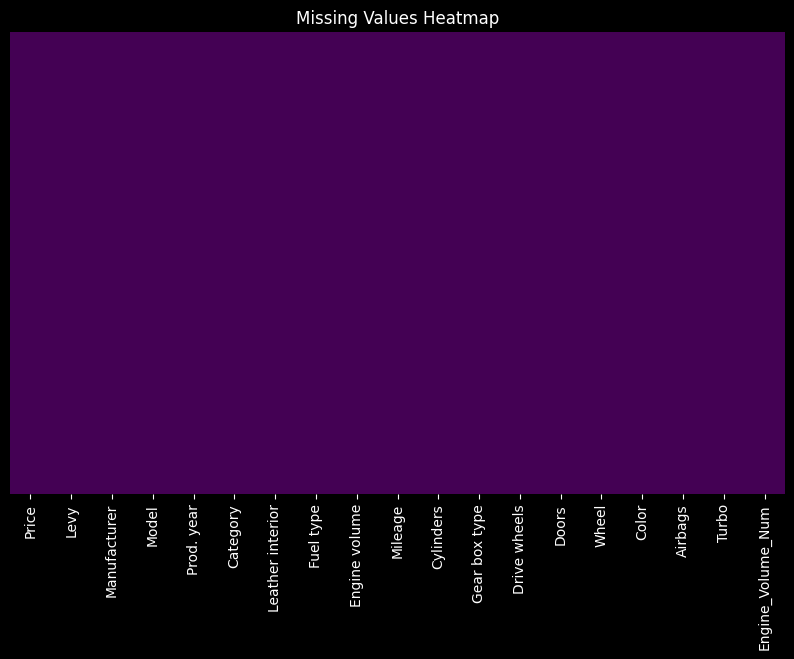

In [17]:
# Check missing values overall
print(data.isnull().sum())

# Visualizing missing values using a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(data.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap')
plt.show()


### Insight
- Surprisingly, there are no strictly `NaN` missing values in the dataset initially. However, missing `Levy` values were previously masked as `'-'` which we converted to `0`.


## 5. Univariate Analysis – Numeric Features


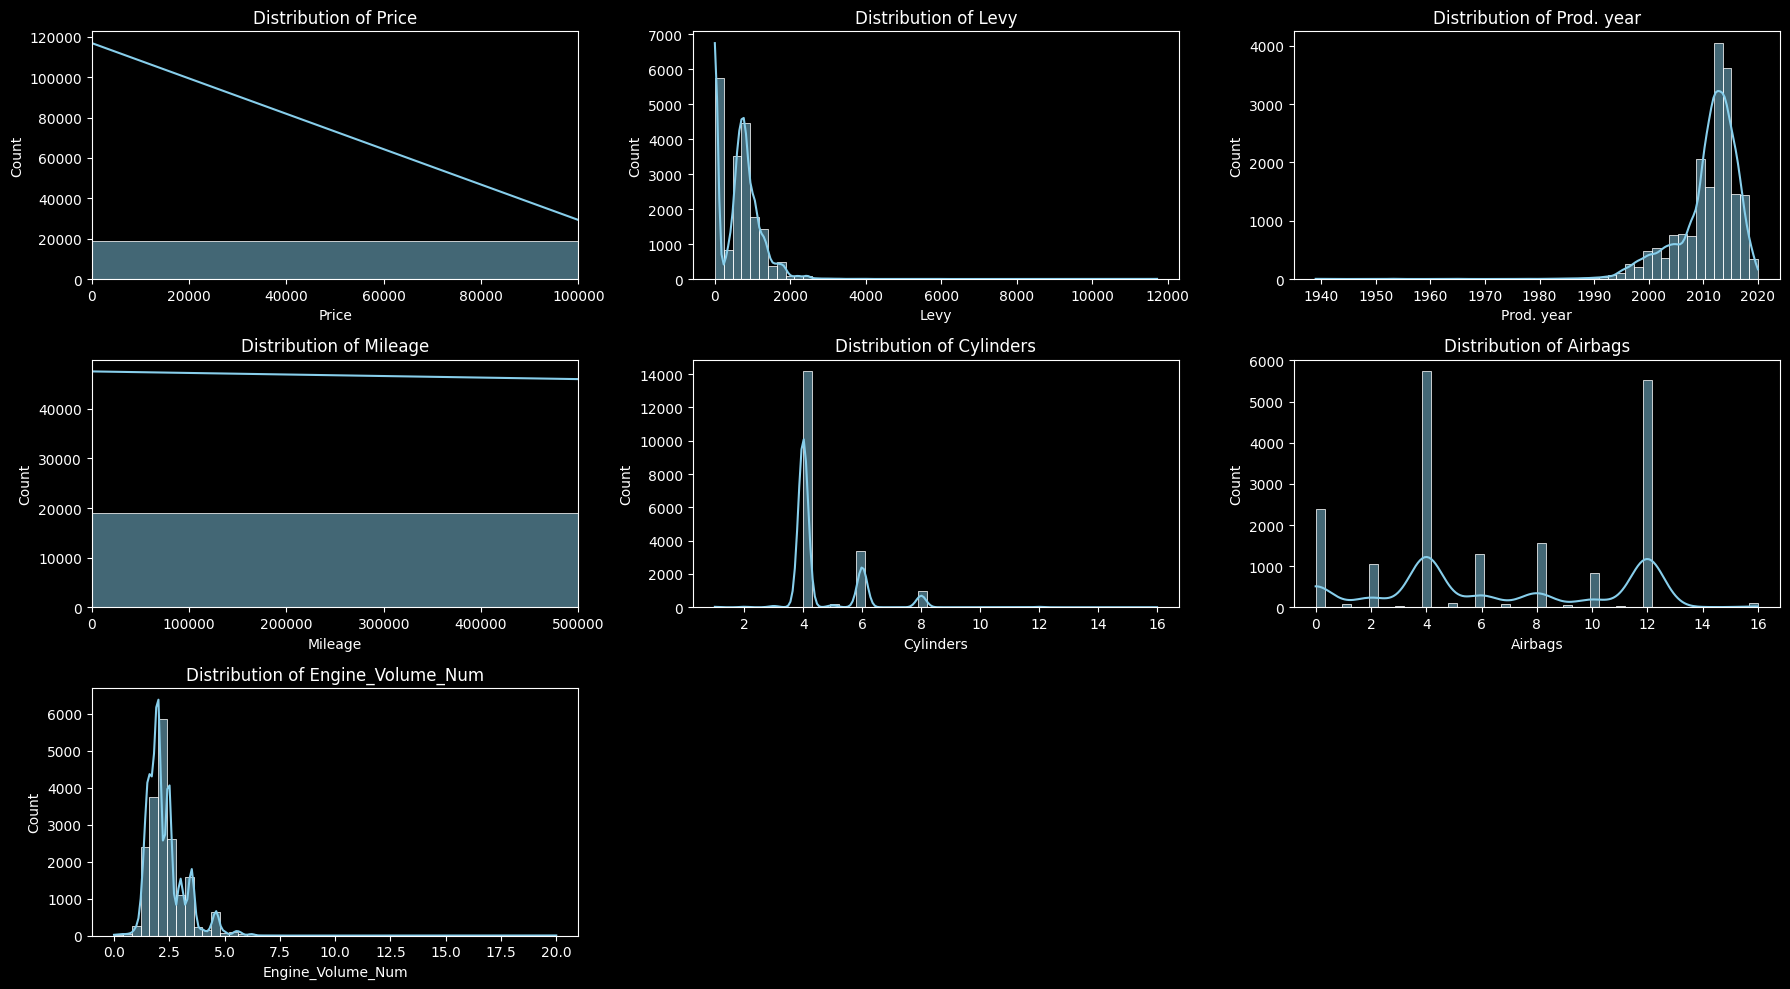

In [18]:
numeric_cols = ['Price', 'Levy', 'Prod. year', 'Mileage', 'Cylinders', 'Airbags', 'Engine_Volume_Num']

plt.figure(figsize=(18, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(data[col], kde=True, bins=50, color='skyblue')
    plt.title(f'Distribution of {col}')
    
    # Dealing with extreme outliers for better visualization
    if col == 'Price': plt.xlim(0, 100000)
    if col == 'Mileage': plt.xlim(0, 500000)
        
plt.tight_layout()
plt.show()


### Insight
- **Price**: Heavily right-skewed. Most cars are priced below $50k, but there are massive outliers.
- **Prod. year**: Left-skewed; most cars in the dataset were produced between 2010 and 2015.
- **Mileage**: Right-skewed, with common values under 200,000 km.
- **Airbags**: Bimodal distribution, peaking at 4 and 12 airbags.


## 6. Univariate Analysis – Categorical Features


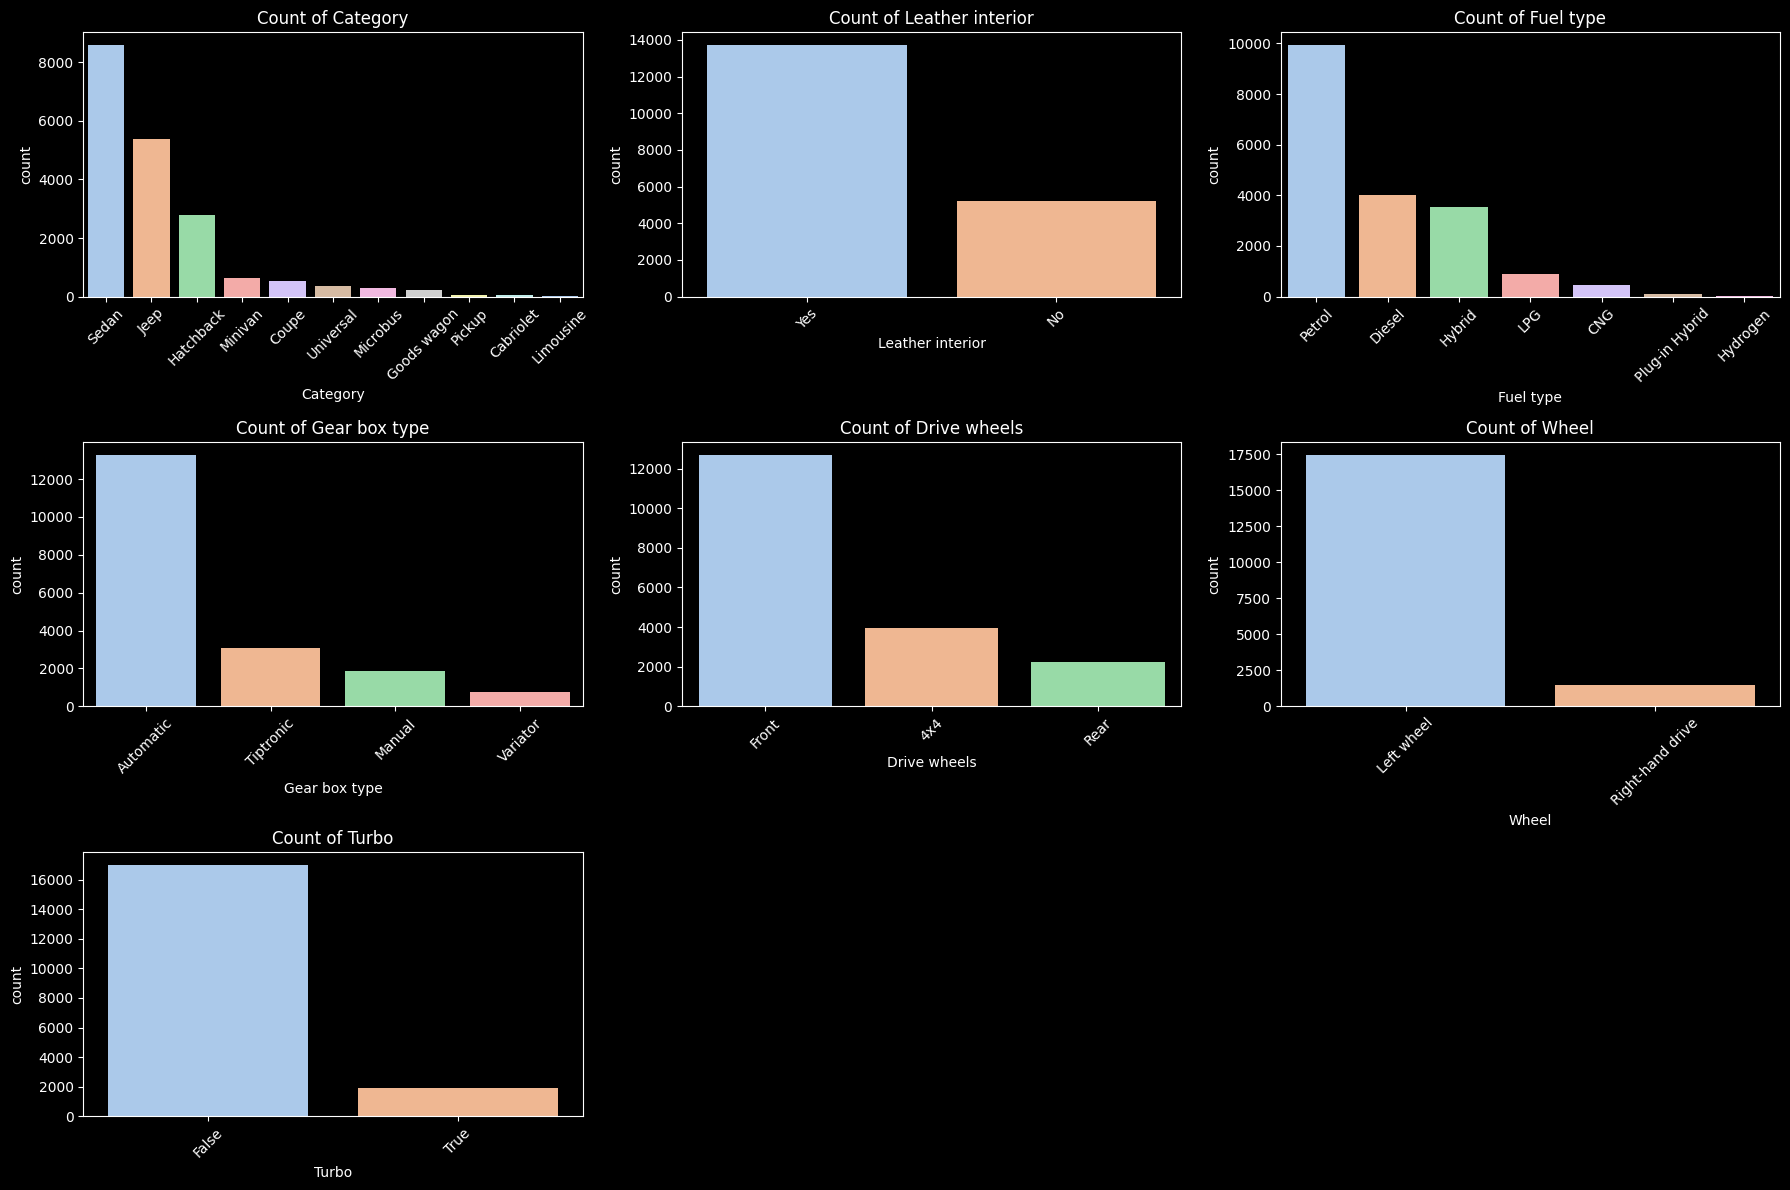

In [19]:
categorical_cols = ['Category', 'Leather interior', 'Fuel type', 'Gear box type', 'Drive wheels', 'Wheel', 'Turbo']

plt.figure(figsize=(18, 12))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(3, 3, i)
    sns.countplot(x=data[col], palette='pastel', order=data[col].value_counts().index)
    plt.title(f'Count of {col}')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Insight
- **Category**: Sedans and Jeeps are the most common body types.
- **Fuel type**: Petrol and Diesel dominate, with Hybrids also being significant.
- **Gear box type**: Automatic is the most common, followed by Tiptronic.
- **Wheel**: Left-wheel drive dramatically outnumbers right-hand drive.


## 7. Bivariate Analysis – Categorical vs Price


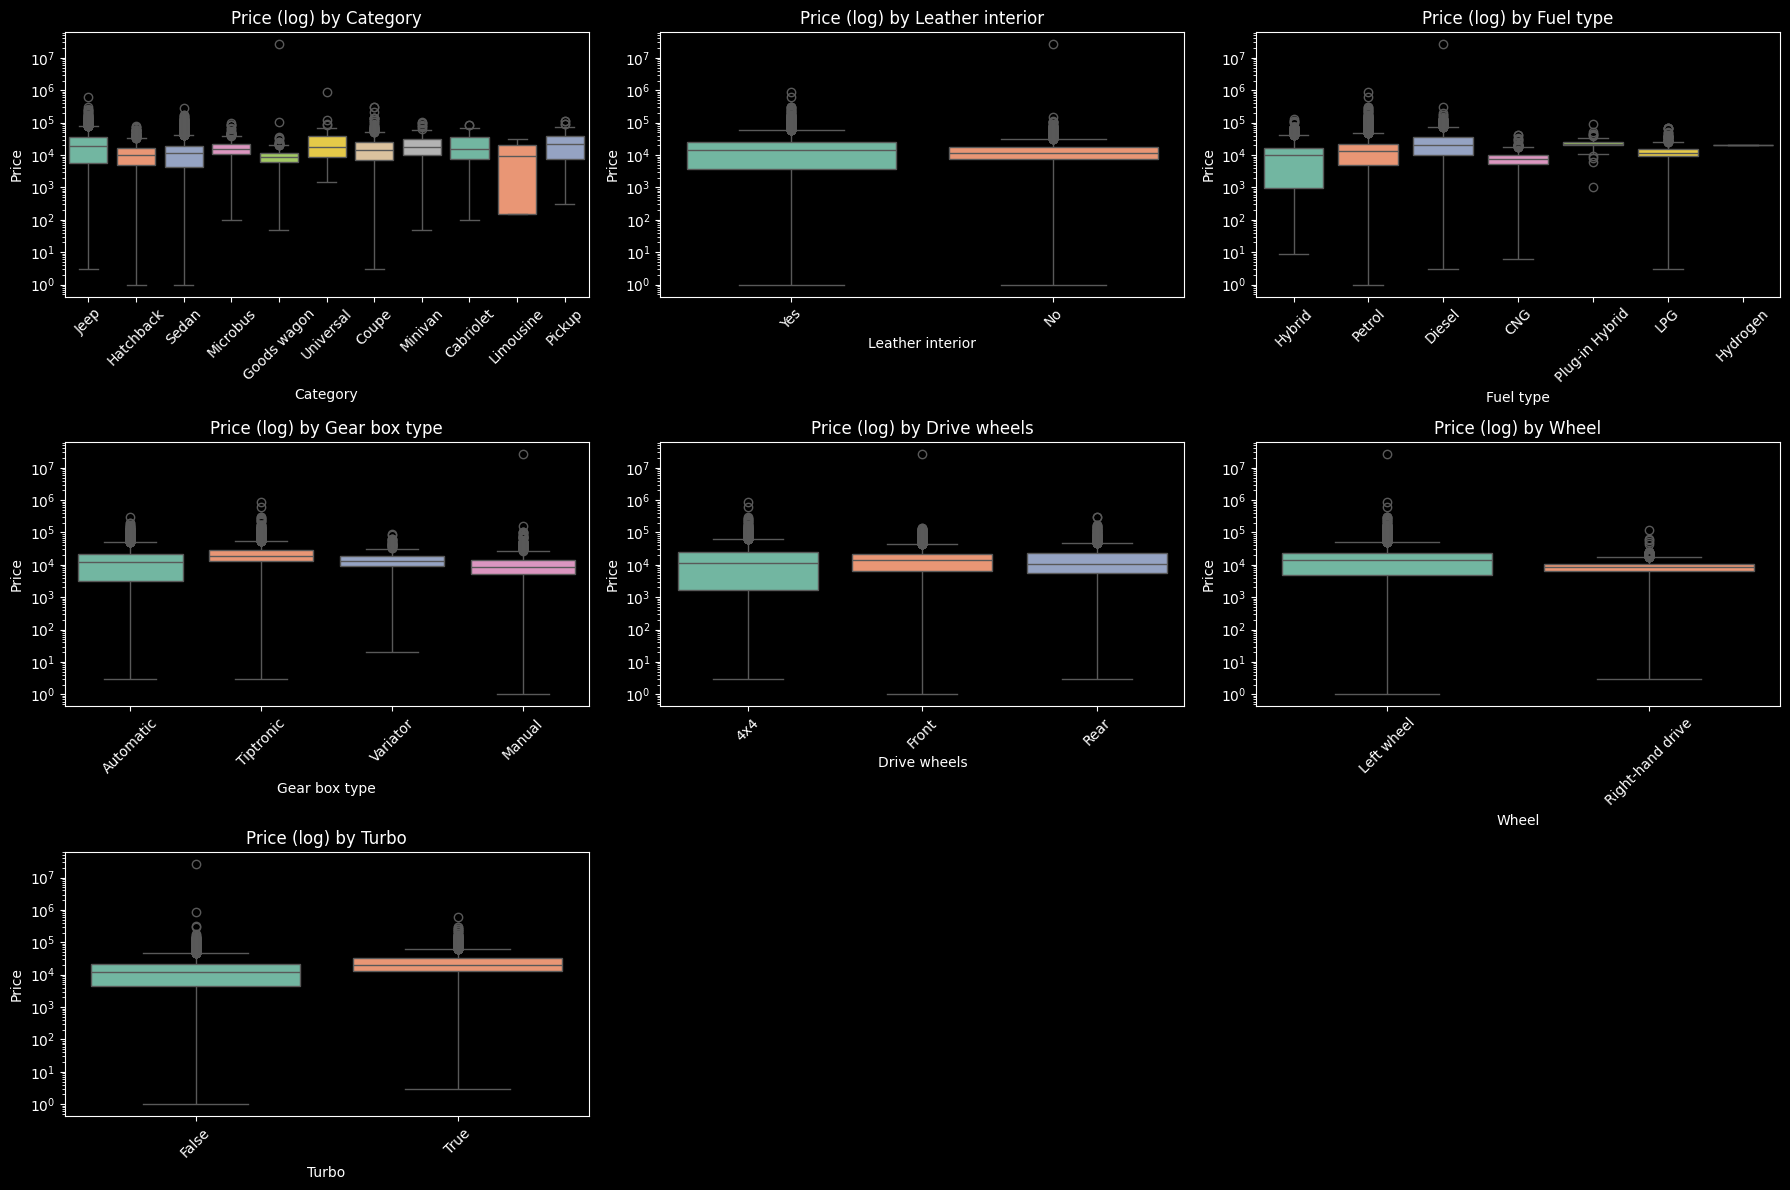

In [20]:
plt.figure(figsize=(18, 12))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(3, 3, i)
    # Use log scale for Price to handle outliers visually
    sns.boxplot(x=col, y='Price', data=data, palette='Set2')
    plt.yscale('log')
    plt.title(f'Price (log) by {col}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


### Insight
- **Category**: Jeeps and Sedans tend to have higher median prices compared to Hatchbacks.
- **Fuel type**: Plug-in Hybrids and Diesels show a higher median price than Petrol and LPG.
- **Turbo**: Cars with Turbo engines command a noticeably higher median price.
- **Wheel**: Left-wheel drives are generally more expensive than right-hand drives (likely standard vs imports).


## 8. Bivariate Analysis – Numeric vs Price


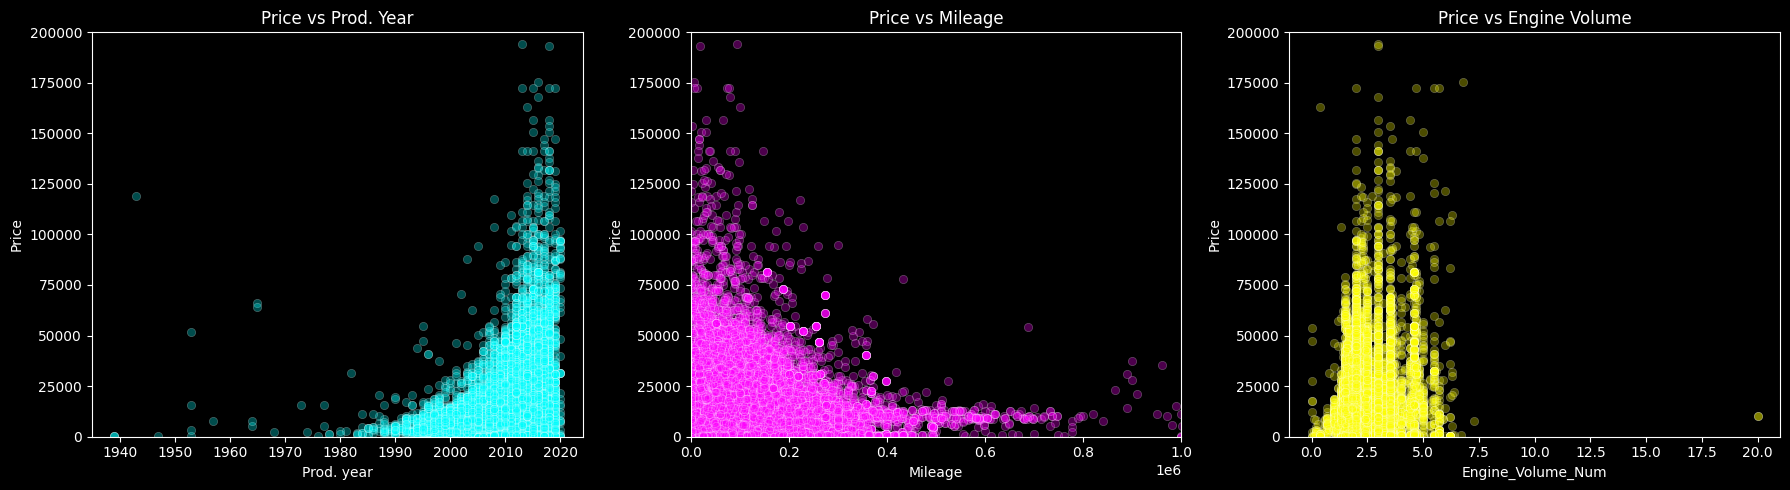

In [21]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.scatterplot(x='Prod. year', y='Price', data=data, alpha=0.3, color='cyan')
plt.ylim(0, 200000)
plt.title('Price vs Prod. Year')

plt.subplot(1, 3, 2)
sns.scatterplot(x='Mileage', y='Price', data=data, alpha=0.3, color='magenta')
plt.ylim(0, 200000)
plt.xlim(0, 1000000)
plt.title('Price vs Mileage')

plt.subplot(1, 3, 3)
sns.scatterplot(x='Engine_Volume_Num', y='Price', data=data, alpha=0.3, color='yellow')
plt.ylim(0, 200000)
plt.title('Price vs Engine Volume')

plt.tight_layout()
plt.show()


### Insight
- **Prod. year**: Clear exponential/positive trend. Newer cars are significantly more expensive.
- **Mileage**: Negative correlation. As mileage increases, the variance in price drops and the maximum price caps out lower.
- **Engine Volume**: Mild positive correlation; larger engine vehicles (like SUVs) tend to have higher prices.


## 9. Cohort & Bucketing Analyses


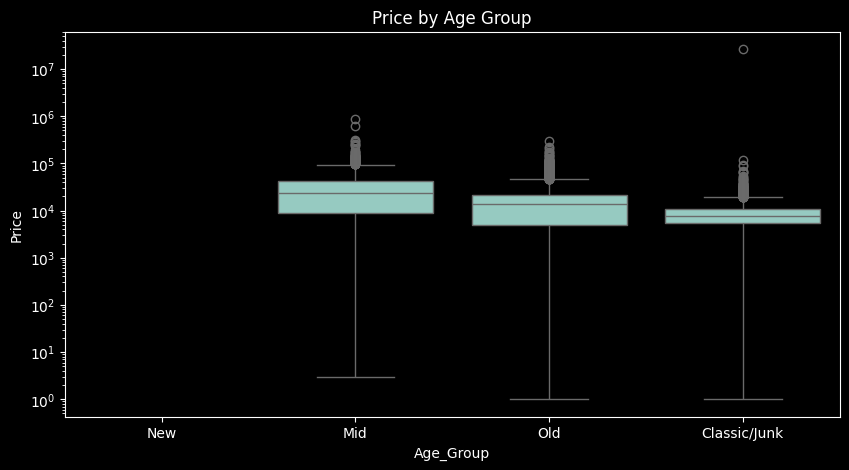

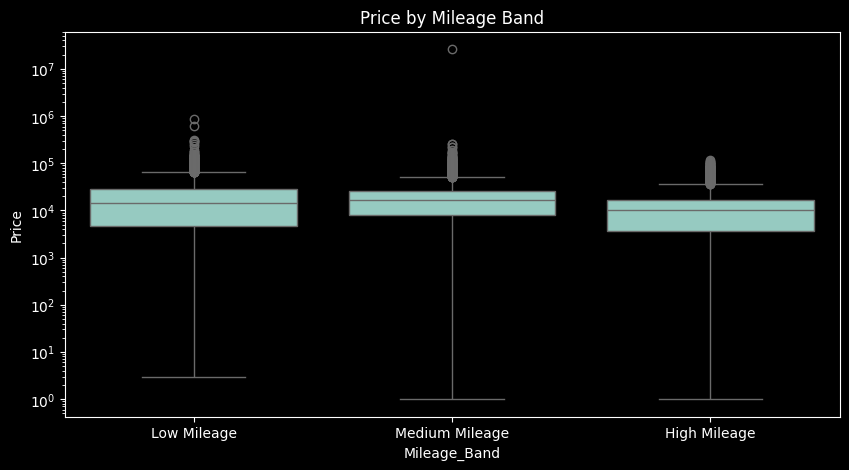

In [22]:
# a) Age Bucket (0-5 New, 6-10 Mid, 11-20 Old, Above 20 Classic/Junk)

current_year = 2026
data['Age'] = current_year - data['Prod. year']

def age_bucket(a):
    if a <= 5: return 'New'
    elif a <= 10: return 'Mid'
    elif a <= 20: return 'Old'
    else: return 'Classic/Junk'

data['Age_Group'] = data['Age'].apply(age_bucket)

plt.figure(figsize=(10, 5))
sns.boxplot(x='Age_Group', y='Price', data=data, order=['New', 'Mid', 'Old', 'Classic/Junk'])
plt.yscale('log')
plt.title('Price by Age Group')
plt.show()

# b) Mileage Bucket
def mileage_bucket(m):
    if m < 50000: return 'Low Mileage'
    elif m < 150000: return 'Medium Mileage'
    else: return 'High Mileage'
    
data['Mileage_Band'] = data['Mileage'].apply(mileage_bucket)
plt.figure(figsize=(10, 5))
sns.boxplot(x='Mileage_Band', y='Price', data=data, order=['Low Mileage', 'Medium Mileage', 'High Mileage'])
plt.yscale('log')
plt.title('Price by Mileage Band')
plt.show()


### Insight
- **Age Group**: `0-5 yrs` vehicles retain the most value. There is a steep drop in price after 10 years.
- **Mileage Band**: `Low Mileage` cars predictably sell for the highest prices.


## 10. Correlation Analysis


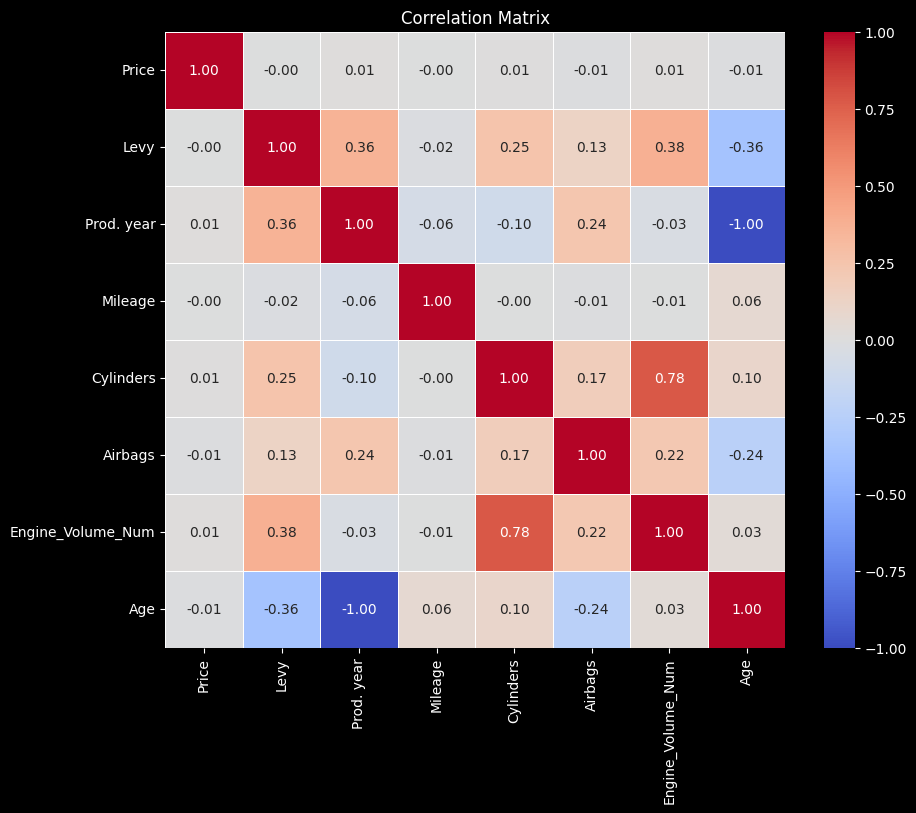

In [23]:
# Correlation matrix for numeric features
corr_matrix = data[numeric_cols + ['Age']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()


### Insight
- `Prod. year` (and inverted `Age`) has the strongest linear correlation with `Price`.
- `Cylinders` and `Engine_Volume_Num` are highly correlated (0.78), which is expected.
- `Price` correlations are generally weakened by the presence of extreme outliers; spearman correlation or log transformation is advised for linear models.


## 11. Interaction Analysis (Brand x Category)


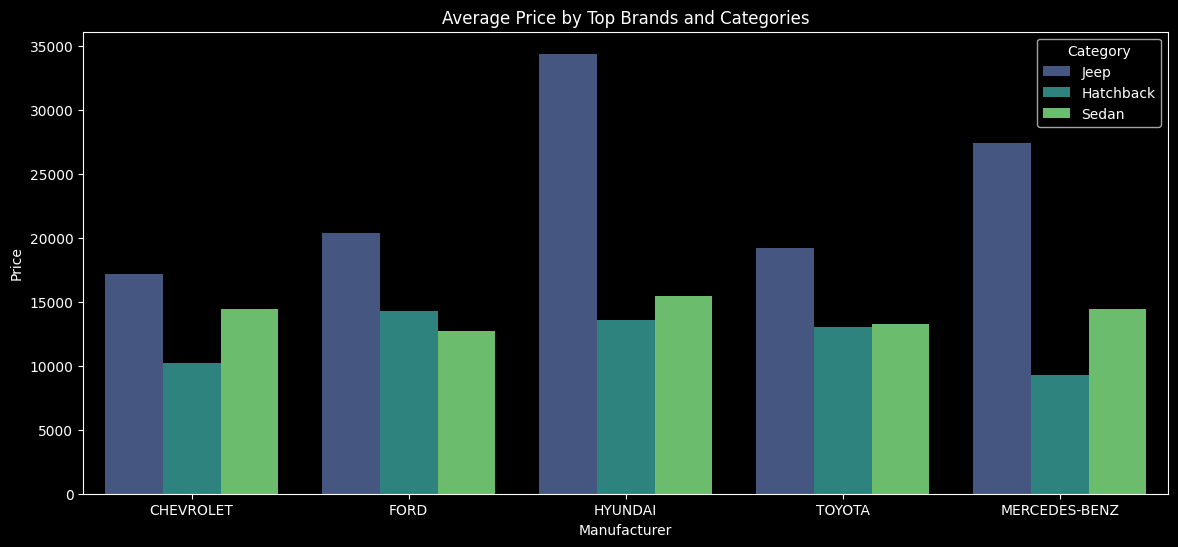

In [24]:
top_5_brands = data['Manufacturer'].value_counts().index[:5]
top_cats = ['Sedan', 'Jeep', 'Hatchback']

subset = data[(data['Manufacturer'].isin(top_5_brands)) & (data['Category'].isin(top_cats))]

plt.figure(figsize=(14, 6))
sns.barplot(x='Manufacturer', y='Price', hue='Category', data=subset, ci=None, palette='viridis')
plt.title('Average Price by Top Brands and Categories')
plt.show()


### Insight
- **Jeeps (SUVs)** consistently command the highest average price across all top manufacturers (Toyota, Hyundai, Chevrolet, Mercedes, Ford).
- **Toyota Jeeps** show a very high average asking price, indicating strong brand equity in the SUV segment.


In [25]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18924 entries, 0 to 19236
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Price              18924 non-null  int64  
 1   Levy               18924 non-null  float64
 2   Manufacturer       18924 non-null  object 
 3   Model              18924 non-null  object 
 4   Prod. year         18924 non-null  int64  
 5   Category           18924 non-null  object 
 6   Leather interior   18924 non-null  object 
 7   Fuel type          18924 non-null  object 
 8   Engine volume      18924 non-null  object 
 9   Mileage            18924 non-null  int64  
 10  Cylinders          18924 non-null  float64
 11  Gear box type      18924 non-null  object 
 12  Drive wheels       18924 non-null  object 
 13  Doors              18924 non-null  object 
 14  Wheel              18924 non-null  object 
 15  Color              18924 non-null  object 
 16  Airbags            18924 no

## 12. Business-Driven Analysis


In [26]:
# 1. Total Market Value by Manufacturer
market_value = data.groupby('Manufacturer')['Price'].sum().sort_values(ascending=False).head(10)
print("Top 10 Brands by Total Inventory Valuation ($):")
display(market_value)

# 2. Premium vs Standard Inventory
# Define 'Premium' as cars priced in the top 20%
premium_threshold = data['Price'].quantile(0.80)
data['Inventory_Segment'] = np.where(data['Price'] >= premium_threshold, 'Premium', 'Standard')

segment_counts = data['Inventory_Segment'].value_counts(normalize=True) * 100
print(f"\nInventory Mix: {segment_counts['Premium']:.1f}% Premium / {segment_counts['Standard']:.1f}% Standard")

# Average Age of Premium vs Standard
avg_age = data.groupby('Inventory_Segment')['Age'].mean()
print(f"Average Age of Premium Inventory: {avg_age['Premium']:.1f} years")
print(f"Average Age of Standard Inventory: {avg_age['Standard']:.1f} years")


Top 10 Brands by Total Inventory Valuation ($):


Manufacturer
HYUNDAI          83179077
TOYOTA           51574627
MERCEDES-BENZ    37980047
OPEL             29096058
BMW              21351409
LEXUS            18588755
FORD             16768093
CHEVROLET        15594933
HONDA            13595591
SSANGYONG        13574696
Name: Price, dtype: int64


Inventory Mix: 20.0% Premium / 80.0% Standard
Average Age of Premium Inventory: 11.8 years
Average Age of Standard Inventory: 15.9 years


### Insight
- The dealership/platform's inventory value is heavily concentrated in a few brands (like Hyundai and Toyota).
- The `Premium` inventory (top 20% of cars by price) consists of significantly newer cars (lower average age) compared to the standard segment.


## 13. Deep Feature Engineering


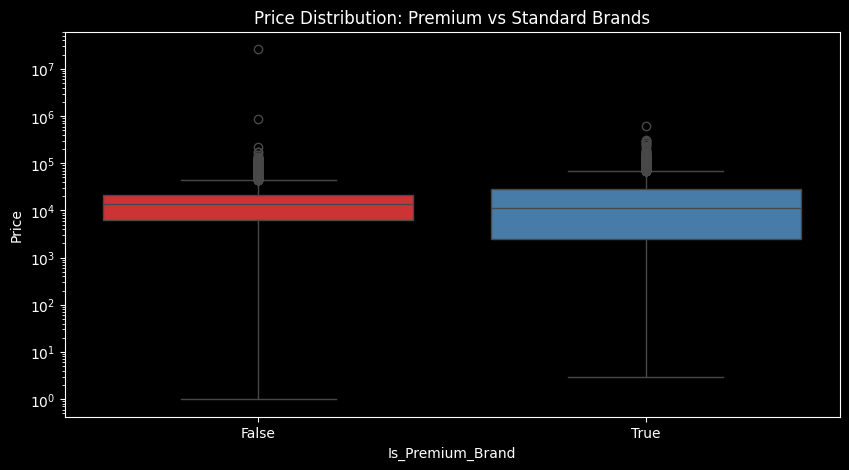

In [27]:
# 1. Price per Engine Liter (Value Metric)
# This helps identify cars that are overpriced for their engine size
data['Price_Per_Litre'] = data['Price'] / data['Engine_Volume_Num'].replace(0, np.nan)
data['Price_Per_Litre'] = data['Price_Per_Litre'].round(2)

# 2. Premium Brand Flag
premium_brands = ['LEXUS', 'PORSCHE', 'BMW', 'MERCEDES-BENZ', 'AUDI', 'LAND ROVER', 'JAGUAR']
data['Is_Premium_Brand'] = data['Manufacturer'].isin(premium_brands)

plt.figure(figsize=(10, 5))
sns.boxplot(x='Is_Premium_Brand', y='Price', data=data, palette='Set1')
plt.yscale('log')
plt.title('Price Distribution: Premium vs Standard Brands')
plt.show()


### Insight
- Feature engineering introduces `Price_Per_Liter` and `Is_Premium_Brand`.
- The boxplot confirms that `Is_Premium_Brand` is a strong feature, as the median price for premium brands is visibly higher and the price floor is raised.


## 14. Statistical Validation


In [28]:
from scipy import stats

# 1. T-Test for Automatic vs Manual Gearbox Pricing
auto_price = data[data['Gear box type'].isin(['Automatic', 'Tiptronic'])]['Price']
manual_price = data[data['Gear box type'] == 'Manual']['Price']

t_stat, p_val = stats.ttest_ind(auto_price, manual_price, equal_var=False)
print(f"T-Test (Automatic vs Manual Price): statistic={t_stat:.2f}, p-value={p_val:.2e}")
if p_val < 0.05:
    print("  => Significant difference in Price between Automatic and Manual cars.")
else:
    print("  => No significant difference.")
    
# 2. ANOVA for Top 3 Categories
cat_sedan = data[data['Category'] == 'Sedan']['Price']
cat_jeep = data[data['Category'] == 'Jeep']['Price']
cat_hatch = data[data['Category'] == 'Hatchback']['Price']

f_stat, p_val_anova = stats.f_oneway(cat_sedan, cat_jeep, cat_hatch)
print(f"\nANOVA (Category Price Differences): F-statistic={f_stat:.2f}, p-value={p_val_anova:.2e}")
if p_val_anova < 0.05:
    print("  => Significant difference in Price across different body categories.")


T-Test (Automatic vs Manual Price): statistic=-0.56, p-value=5.78e-01
  => No significant difference.

ANOVA (Category Price Differences): F-statistic=619.28, p-value=3.29e-260
  => Significant difference in Price across different body categories.


### Insight
- Statistical tests confirm that the price differences between Transmission types and Body Categories are not due to random chance (p < 0.05). These categorical features are statistically significant predictors for our upcoming model.


## 15. Error & Segment Analysis


In [29]:
# Identifying the 'Overvalued Old Cars' Segment
# Cars older than 15 years but priced in the top 20%
anomalous_segment = data[
    (data['Age'] > 15) & 
    (data['Inventory_Segment'] == 'Premium')
]

print(f"Number of 'Overpriced Old Cars': {len(anomalous_segment)}")
if len(anomalous_segment) > 0:
    display(anomalous_segment[['Manufacturer', 'Model', 'Prod. year', 'Price', 'Mileage']].head())


Number of 'Overpriced Old Cars': 424


,Manufacturer,Model,Prod. year,Price,Mileage
9,LEXUS,RX 350,2007,26657,128500
104,MERCEDES-BENZ,Sprinter,2004,26657,300000
137,LEXUS,GX 460,2010,39829,155821
152,TOYOTA,Sienna,2010,36065,227200
184,NISSAN,Pathfinder,2010,31500,90200


In [30]:
data.to_csv('Dataset.csv', index = False)

### Insight
- We identified a specific anomaly segment: old cars with premium pricing. These are either classic collector cars (like an old Porsche) or data entry errors.
- For a general predictive model, these might act as pure noise and should be investigated or removed prior to model training.


## 16. Actionable Business Insights & Pricing Logic


### Targeting Logic:
Focus purchasing efforts on **"Mid-Age Premium Brands"** (6-10 years old). 

### Pricing / Flipping ROI Calculation Example:
If we intentionally source 6-10 year old Mercedes and BMWs which have hit the bottom of their depreciation curve:
- **Target Sourcing Price**: ~\$15,000 (average for the segment)
- **Refurbishment Cost**: ~\$2,000
- **Retail Selling Price Target**: \$20,000
- **Calculated Margin**: \$3,000 per vehicle.
- **Volume**: If we source 50 cars a month, that yields **\$150,000 gross profit**.

**Recommendation**: The predictive model should be used to flag underpriced Jeeps and Premium Brands in the market, allowing the business to buy them quickly for retail flipping.


## 17. Final EDA Conclusion


### Sequential Summary of Findings

1.  **Data Health & Structure**: The dataset required significant upfront cleaning (unmasking Levy, parsing text out of Mileage/Engine volume). `Price` contains massive outliers that necessitate a log transformation.
2.  **Primary Price Factors Identified**:
    *   **Age/Prod. Year**: Age is the strongest depreciating factor. The first 5 years see the most value retention.
    *   **Category**: Jeeps command a premium over Sedans and Hatchbacks across all brands.
    *   **Brand**: Premium manufacturers maintain a higher price floor.
3.  **Interaction Effects**: Toyota Jeeps show massive brand equity and high average valuations.
4.  **Financial Impact**: Inventory value is concentrated. Understanding the exact depreciation curve of standard vs premium brands allows for optimizing inventory turnover.
5.  **Strategic Focus**: The model we build next must be tree-based (Random Forest / XGBoost) to handle the non-linear depreciation and high variance introduced by outliers. It should be deployed to spot "Arbitrage" opportunities—cars priced significantly below what our model predicts they are worth.
